# NCAA Men's March Madness Factor Importance

This notebook measures how pre-tournament Four Factors and miscellaneous team
statistics contribute to tournament predictions. It compares four model
families, calibrates their probabilities, and measures importance only on
future held-out seasons.

Tournament seed, KenPom rank, net rating, luck, and adjusted efficiency are
excluded from model inputs. Features are computed exclusively from NCAA
regular-season detailed box scores using KenPom-compatible formulas.

In [1]:
from pathlib import Path
import json
import os
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

from src.analyze_factor_importance import main as run_analysis
from src.download_ncaa_data import main as download_ncaa_data

REPORTS = PROJECT_ROOT / "reports"
FIGURES = REPORTS / "figures"
PROJECT_ROOT

PosixPath('/Users/edwardluo/Documents/Codex/2026-05-05/create-a-decision-tree-machine-learning')

## Factor Reference

The complete data dictionary below defines each raw factor, its offensive and
defensive direction, its matchup interpretation, and every engineered feature.

In [2]:
display(Markdown((PROJECT_ROOT / "docs" / "factor_reference.md").read_text()))

# Factor Reference

This reference defines every base basketball factor and engineered matchup
concept used by the factor-importance model. The formulas below describe this
project's implementation exactly.

## Reading The Features

All percentages are calculated from NCAA regular-season detailed box scores and
multiplied by 100. Tournament games are stored separately and never contribute
to a team's feature snapshot.

Raw rates are converted to within-season percentile strengths before matchup
features are constructed:

- `1.00` means one of the strongest values in that season.
- `0.50` is approximately average.
- `0.00` means one of the weakest values in that season.
- Lower-is-better statistics are reversed before percentile ranking.
- A positive matchup feature favors Team A; a negative value favors Team B.

Team A is assigned by a deterministic hash rather than by winner, favorite, or
seed. This prevents the row orientation from leaking the outcome.

## Possession Estimate

Most turnover and steal rates use estimated possessions:

```text
team possessions = FGA + 0.475 * FTA - OR + TO
opponent possessions = opponent FGA + 0.475 * opponent FTA
                       - opponent OR + opponent TO
possessions = (team possessions + opponent possessions) / 2
```

Using the average of both estimates reduces box-score bookkeeping noise.

## Four Factors

### Effective Field-Goal Percentage

**Feature family:** `efg`

```text
Offensive eFG% = 100 * (FGM + 0.5 * 3PM) / FGA
Defensive eFG% = 100 * (opponent FGM + 0.5 * opponent 3PM) / opponent FGA
```

Effective field-goal percentage gives an extra half-make of credit to a made
three because a three is worth 50% more than a two. It captures shooting
accuracy and shot value in one number.

- Higher offensive eFG% is better.
- Lower defensive eFG% allowed is better.
- Offensive strength can reflect shot quality, shooting talent, spacing, and
  finishing.
- Defensive strength can reflect contest quality, rim protection, scheme, and
  forcing inefficient shot locations.

**Strength vs strength:** an elite shooting offense meets a defense that is
elite at suppressing shot value. The result indicates which side's advantage
has historically translated more strongly after accounting for the reverse
matchup.

**Strength vs weakness:** an elite shooting offense meets a defense that allows
high eFG%. This is a favorable efficiency mismatch, but three-point variance can
still make a single-game result volatile.

**Caution:** eFG% describes outcomes, not the exact shot-quality process. Two
teams can have the same eFG% with very different three-point volume and rim-shot
profiles.

### Turnover Percentage

**Feature family:** `turnover`

```text
Offensive TO% = 100 * team turnovers / possessions
Defensive TO% = 100 * opponent turnovers / possessions
```

Turnover percentage estimates how frequently a possession ends without a shot
or free-throw opportunity.

- Lower offensive TO% is better because the offense protects possessions.
- Higher defensive TO% is better because the defense ends opponent possessions.
- The separate steal and non-steal-turnover factors explain how those turnovers
  occur.

**Strength vs strength:** a low-turnover offense faces a high-turnover defense.
This is a direct contest between ball security and disruption.

**Strength vs weakness:** a careful offense faces a defense that rarely forces
turnovers, or a disruptive defense faces a careless offense. The second case
can create transition chances in addition to denying shots.

**Caution:** turnover rates depend on style and opponent pressure. A team can
accept more turnovers while creating higher-value shots on its successful
possessions.

### Offensive Rebounding Percentage

**Feature family:** `offensive_rebound`

```text
Offensive OR% = 100 * team OR / (team OR + opponent DR)
Defensive OR% allowed = 100 * opponent OR / (opponent OR + team DR)
```

Offensive rebounding percentage estimates the share of available offensive
rebounds captured. The defensive version measures the share conceded.

- Higher offensive OR% is better.
- Lower defensive OR% allowed is better.
- Offensive strength creates second-chance possessions and can draw fouls.
- Defensive strength finishes stops and limits repeated shot attempts.

**Strength vs strength:** an elite offensive rebounding team meets an elite
defensive rebounding team. This is the clearest example of a direct Four Factors
collision.

**Strength vs weakness:** a strong offensive rebounding team faces a poor
defensive rebounding team. The offense may gain extra attempts even if its
first-shot efficiency is ordinary.

**Caution:** teams that prioritize transition defense may intentionally send
fewer players to the offensive glass. OR% therefore reflects both ability and
strategic choice.

### Free-Throw Rate

**Feature family:** `free_throw_rate`

```text
Offensive FTRate = 100 * FTA / FGA
Defensive FTRate allowed = 100 * opponent FTA / opponent FGA
```

Free-throw rate measures how frequently a team earns free-throw attempts
relative to field-goal attempts.

- Higher offensive FTRate is better in the model's directional ranking.
- Lower defensive FTRate allowed is better.
- Offensive strength often reflects rim pressure, physicality, and foul drawing.
- Defensive strength reflects defending without fouling.

**Strength vs strength:** a foul-drawing offense faces a defense that avoids
fouls. The matchup can depend heavily on personnel, officiating, and whether the
offense reaches the paint.

**Strength vs weakness:** a high-FTRate offense faces a foul-prone defense,
creating a potential efficiency and lineup-depth advantage.

**Caution:** this implementation uses attempts divided by field-goal attempts.
It does not directly include free-throw accuracy, which is modeled separately.

## Miscellaneous Shooting Factors

### Three-Point Percentage

**Feature family:** `three_point`

```text
Offensive 3P% = 100 * 3PM / 3PA
Defensive 3P% allowed = 100 * opponent 3PM / opponent 3PA
```

- Higher offensive 3P% is better.
- Lower defensive 3P% allowed is better.
- It isolates perimeter conversion from two-point shooting.

**Matchup meaning:** strength vs strength compares elite perimeter shooting with
elite suppression. Strength vs weakness identifies an offense capable of
punishing a defense that has allowed efficient three-point shooting.

**Caution:** three-point percentage is volatile in small samples, and defensive
3P% can contain more shooting luck than statistics such as attempt location or
contest quality.

### Two-Point Percentage

**Feature family:** `two_point`

```text
2PM = FGM - 3PM
2PA = FGA - 3PA
Offensive 2P% = 100 * 2PM / 2PA
Defensive 2P% allowed = 100 * opponent 2PM / opponent 2PA
```

- Higher offensive 2P% is better.
- Lower defensive 2P% allowed is better.
- It combines rim finishing, post play, and midrange shooting.

**Matchup meaning:** strength vs strength often represents finishing against rim
protection or disciplined interior defense. Strength vs weakness can expose a
defense that struggles to protect the paint.

**Caution:** without shot-location data, the factor cannot distinguish rim
attempts from midrange attempts.

### Free-Throw Percentage

**Feature family:** `free_throw_pct`

```text
Offensive FT% = 100 * FTM / FTA
Defensive opponent FT% = 100 * opponent FTM / opponent FTA
```

- Higher offensive FT% is better.
- Lower opponent FT% is treated as stronger defense for consistent directional
  feature construction.
- Offensive FT% helps determine whether foul drawing becomes actual scoring.

**Matchup meaning:** offensive FT% is largely a team skill rather than a direct
interaction with the opponent. The defensive value should be interpreted with
care because defenses have limited control over opponent free-throw accuracy.

**Caution:** defensive opponent FT% may mostly reflect opponent mix and random
variation. A low importance estimate is therefore unsurprising.

## Miscellaneous Ball-Security Factors

### Block Rate

**Feature family:** `block`

```text
Offensive block rate = 100 * opponent blocks / team 2PA
Defensive block rate = 100 * team blocks / opponent 2PA
```

The offensive version measures how often a team's two-point attempts are
blocked; the defensive version measures rim disruption.

- Lower offensive block rate is better.
- Higher defensive block rate is better.

**Strength vs strength:** an offense that rarely gets blocked faces an elite
shot-blocking defense. **Strength vs weakness:** a strong rim-protecting defense
faces an offense whose two-point attempts are blocked frequently.

**Caution:** blocks capture only some rim deterrence. Great interior defenders
can alter or discourage attempts without recording a block.

### Steal Rate

**Feature family:** `steal`

```text
Offensive steal rate allowed = 100 * opponent steals / possessions
Defensive steal rate = 100 * team steals / possessions
```

- Lower offensive steal rate allowed is better.
- Higher defensive steal rate is better.
- Steals are especially valuable because they often create transition offense.

**Strength vs strength:** a secure offense faces an aggressive defense that
creates live-ball turnovers. **Strength vs weakness:** a high-steal defense
faces a team vulnerable to ball pressure.

**Caution:** aggressive steal attempts can also create defensive breakdowns;
the rate does not directly measure that tradeoff.

### Non-Steal Turnover Rate

**Feature family:** `nonsteal_turnover`

```text
Offensive non-steal TO% = 100 * max(team TO - opponent steals, 0) / possessions
Defensive non-steal TO% = 100 * max(opponent TO - team steals, 0) / possessions
```

This separates dead-ball and uncredited turnovers from steals. Examples include
travels, offensive fouls, shot-clock violations, and passes out of bounds.

- Lower offensive non-steal TO% is better.
- Higher defensive non-steal TO% is treated as better.

**Matchup meaning:** it helps distinguish general ball security from specific
vulnerability to steals. A strength-vs-weakness edge can indicate an offense
that avoids unforced mistakes against a defense that creates few non-steal
turnovers, or the reverse.

**Caution:** subtracting steals is a box-score approximation; turnover and steal
bookkeeping do not always map perfectly one to one.

## Miscellaneous Creation And Style Factors

### Assist Rate

**Feature family:** `assist`

```text
Offensive assist rate = 100 * team assists / team FGM
Defensive assist rate allowed = 100 * opponent assists / opponent FGM
```

- Higher offensive assist rate is treated as stronger creation.
- Lower opponent assist rate is treated as stronger defense.
- It describes how often made baskets are assisted, not total passing quality.

**Matchup meaning:** strength vs strength compares a high-assist offense with a
defense that suppresses assisted baskets. Strength vs weakness can identify a
passing offense facing a defense prone to losing structure.

**Caution:** assist rate is strongly affected by scorekeeper conventions,
offensive system, and shot mix. Isolation-heavy teams can be excellent offenses
with modest assist rates.

### Three-Point Attempt Rate

**Feature family:** `three_point_rate`

```text
Offensive 3PA rate = 100 * team 3PA / team FGA
Defensive 3PA rate allowed = 100 * opponent 3PA / opponent FGA
```

Three-point attempt rate is treated as style, not as inherently good or bad. Its
within-season percentile measures how perimeter-oriented a team or its opponent
shot profile is.

- High offensive rate means a larger share of shots are threes.
- High defensive rate means opponents take a larger share of shots from three.
- `three_point_rate_environment` measures the overall likelihood that a matchup
  will be three-point heavy.
- `three_point_leverage_edge` increases the impact of a three-point efficiency
  advantage when the matchup is expected to generate high three-point volume.

**Caution:** volume creates both scoring upside and single-game variance. A high
attempt rate is not automatically a strength.

## Per-Factor Engineered Matchup Features

For every strength-based factor above, let:

- `A_off` = Team A offensive strength percentile.
- `A_def` = Team A defensive strength percentile.
- `B_off` = Team B offensive strength percentile.
- `B_def` = Team B defensive strength percentile.

The model creates the following features for each factor.

### Raw Offensive And Defensive Differences

```text
raw offensive difference = direction * (Team A raw offense - Team B raw offense)
raw defensive difference = direction * (Team A raw defense - Team B raw defense)
```

These features preserve the original percentage-point distance between teams.
The direction is reversed for lower-is-better rates, so a positive value always
favors Team A. They complement percentile features: percentiles describe
relative standing within a season, while raw differences preserve whether the
underlying gap is small or large.

### Offensive Strength Difference

```text
A_off - B_off
```

Compares the teams' offensive ability in the same factor without considering
the opposing defenses.

### Defensive Strength Difference

```text
A_def - B_def
```

Compares the teams' defensive ability in the same factor.

### Overall Strength Difference

```text
(A_off + A_def - B_off - B_def) / 2
```

Summarizes two-way strength in that factor.

### Net Matchup Edge

```text
(A_off - B_def) - (B_off - A_def)
```

Compares Team A's offensive matchup with Team B's offensive matchup. Positive
values indicate the factor-level matchup favors Team A on balance.

### Net Strength Vs Strength

```text
A_off * B_def - B_off * A_def
```

Emphasizes games in which strong offense meets strong defense, then compares
that collision with the reverse side of the matchup.

### Net Strength Vs Weakness

```text
A_off * (1 - B_def) - B_off * (1 - A_def)
```

Emphasizes opportunities for a strong offense to attack a weak defense.

### Net Weakness Vs Strength

```text
(1 - A_off) * B_def - (1 - B_off) * A_def
```

Emphasizes cases in which an offensive weakness runs into an opposing defensive
strength.

## Three-Point Style Features

Because three-point attempt rate is a neutral style variable, it uses different
transformations:

- `off_style_diff`: difference between offensive 3PA-rate percentiles.
- `def_style_diff`: difference between defensive 3PA-rate-allowed percentiles.
- `expected_diff`: difference in each team's expected three-point environment.
- `environment`: average of both teams' offensive and defensive 3PA-rate
  percentiles; high values indicate a three-point-heavy matchup.

## Composite Features

### Four Factor Edge Mean

The average net matchup edge across eFG%, turnover percentage, offensive
rebounding percentage, and free-throw rate. It estimates broad matchup quality.

### Four Factor Edge Minimum And Maximum

The weakest and strongest of the four net matchup edges. The minimum captures a
potential vulnerability; the maximum captures a standout advantage.

### Four Factor Edge Standard Deviation

The dispersion of the four matchup edges. A high value means the matchup is
uneven, with pronounced strengths and weaknesses rather than a uniform edge.

### Four Factor Positive Edge Count

The number of positive Four Factor edges minus the number of negative edges. It
ranges from `-4` to `4` and measures breadth of matchup advantages.

### Possession Creation Edge

The average turnover and offensive-rebounding net edges. It summarizes which
team is more likely to create extra shot opportunities.

### Shooting Pressure Edge

The average eFG% and free-throw-rate net edges. It combines shot efficiency with
the ability to pressure the defense and reach the line.

### Perimeter Edge

The average eFG% and three-point-percentage net edges. It summarizes shooting
value with an emphasis on perimeter conversion.

### Interior Edge

The average two-point, offensive-rebounding, free-throw-rate, and block-rate net
edges. It represents paint scoring, second chances, foul pressure, and rim
protection together.

### Ball Security Edge

The average overall turnover, steal, and non-steal-turnover net edges. It
separates possession protection and disruption into related components.

### Four Factor Balance Difference

For each team, take its weakest average offense-defense percentile among the
Four Factors. The feature is Team A's weakest value minus Team B's weakest
value. It rewards teams without an obvious Four Factors deficiency.

### Four Factor Breadth Difference

Counts how many Four Factors have an average offense-defense percentile of at
least `0.67` for each team, then subtracts Team B's count from Team A's.

### Strength Vs Strength Composite

The average net strength-vs-strength term across all Four Factors and
miscellaneous strength factors.

### Weakness Exploitation Composite

The average net strength-vs-weakness term across all Four Factors and
miscellaneous strength factors.

### Three-Point Leverage Edge

```text
three-point net matchup edge * three-point-rate environment
```

This gives more weight to a perimeter-efficiency advantage when both teams'
profiles suggest that many shots will come from three.

## Interpreting Importance

The individual chart reports the increase in held-out log loss after shuffling
one feature within each validation season. The grouped chart shuffles all
features belonging to a basketball concept together.

- Larger positive importance means the fitted model relied more on the feature.
- Near-zero importance means the feature added little unique held-out signal.
- Negative importance can occur when noise or correlation makes a feature
  slightly harmful on a particular sample.
- Correlated features share predictive credit, so exact individual rankings can
  understate the importance of a broader concept.
- Importance is not causality. It does not prove that changing a factor by a
  specified amount will cause a corresponding change in win probability.
- Stability across held-out seasons and agreement across model families are more
  trustworthy than a single importance estimate.


## 1. Prepare NCAA Data

Raw data are downloaded only when required files are missing. They remain
excluded from Git.

In [3]:
required_files = [
    PROJECT_ROOT / "data/raw/MTeams.csv",
    PROJECT_ROOT / "data/raw/MNCAATourneyCompactResults.csv",
    PROJECT_ROOT / "data/raw/MNCAATourneySeeds.csv",
    PROJECT_ROOT / "data/raw/MRegularSeasonDetailedResults.csv",
]

if not all(path.exists() for path in required_files):
    download_ncaa_data()
else:
    print("NCAA source files already available.")

NCAA source files already available.


## 2. Build Features, Train Models, And Validate

This single entry point rebuilds the pre-tournament team features, engineers
matchup variables, compares and calibrates all candidate models, and writes
the model and reports.

In [4]:
run_analysis()

metrics = json.loads((REPORTS / "metrics.json").read_text())
comparison = pd.read_csv(REPORTS / "model_comparison.csv")

print("Selected model:", metrics["selected_model"])
print("Pre-tournament timing:", metrics["snapshot_status"])
print("Importance gate passed:", metrics["trustworthiness"]["importance_gate_passed"])
comparison

Wrote data/processed/pretournament_team_factors.csv with 7,255 team-seasons
Confirmed pre-tournament seasons: 2003-2023
Excluded incomplete seasons: {'2024': 100}


{
  "selected_model": "hist_gradient_boosting",
  "metrics": {
    "raw_accuracy": 0.6508728179551122,
    "raw_brier": 0.22346377696902392,
    "raw_log_loss": 0.6402707745465762,
    "raw_roc_auc": 0.6943380267675008,
    "calibrated_accuracy": 0.6583541147132169,
    "calibrated_brier": 0.22179767465657046,
    "calibrated_log_loss": 0.6343456088115559,
    "calibrated_roc_auc": 0.6943380267675008,
    "training_cv_accuracy": 0.6231003039513677,
    "training_cv_brier": 0.23387034486533,
    "training_cv_log_loss": 0.6657187349230299,
    "training_cv_roc_auc": 0.6774360538746683
  },
  "trustworthiness": {
    "importance_gate_passed": true,
    "selection_accuracy_auc_gate_passed": true,
    "validation_used_for_model_family_selection": true,
    "final_untouched_test_set_available": false,
    "accuracy_wilson_95": [
      0.6106281662679696,
      0.7030747733508838
    ],
    "stable_features_in_top_15": 14,
    "minimum_stability_definition": "positive permutation importance i

,model,raw_accuracy,raw_brier,raw_log_loss,raw_roc_auc,calibrated_accuracy,calibrated_brier,calibrated_log_loss,calibrated_roc_auc,training_cv_accuracy,training_cv_brier,training_cv_log_loss,training_cv_roc_auc
0,regularized_logistic,0.618454,0.218799,0.625251,0.706876,0.615960,0.215648,0.618124,0.706876,0.656535,0.214964,0.614120,0.719164
1,soft_voting_ensemble,0.625935,0.221109,0.632316,0.694537,0.625935,0.219877,0.629369,0.696776,0.635258,0.218361,0.623969,0.705150
2,random_forest,0.610973,0.222284,0.634207,0.687945,0.610973,0.222152,0.633896,0.687945,0.644377,0.217541,0.621336,0.701785
3,hist_gradient_boosting,0.650873,0.223464,0.640271,0.694338,0.658354,0.221798,0.634346,0.694338,0.623100,0.233870,0.665719,0.677436
4,decision_tree,0.598504,0.260911,0.829986,0.634248,0.598504,0.237462,0.677741,0.634248,0.623100,0.245535,0.752126,0.662803


## 3. Feature Importance

Bars show the held-out increase in log loss when each feature is shuffled
within a validation season. Whiskers capture uncertainty across seasons and
repeated shuffles. Larger positive values indicate greater predictive reliance.

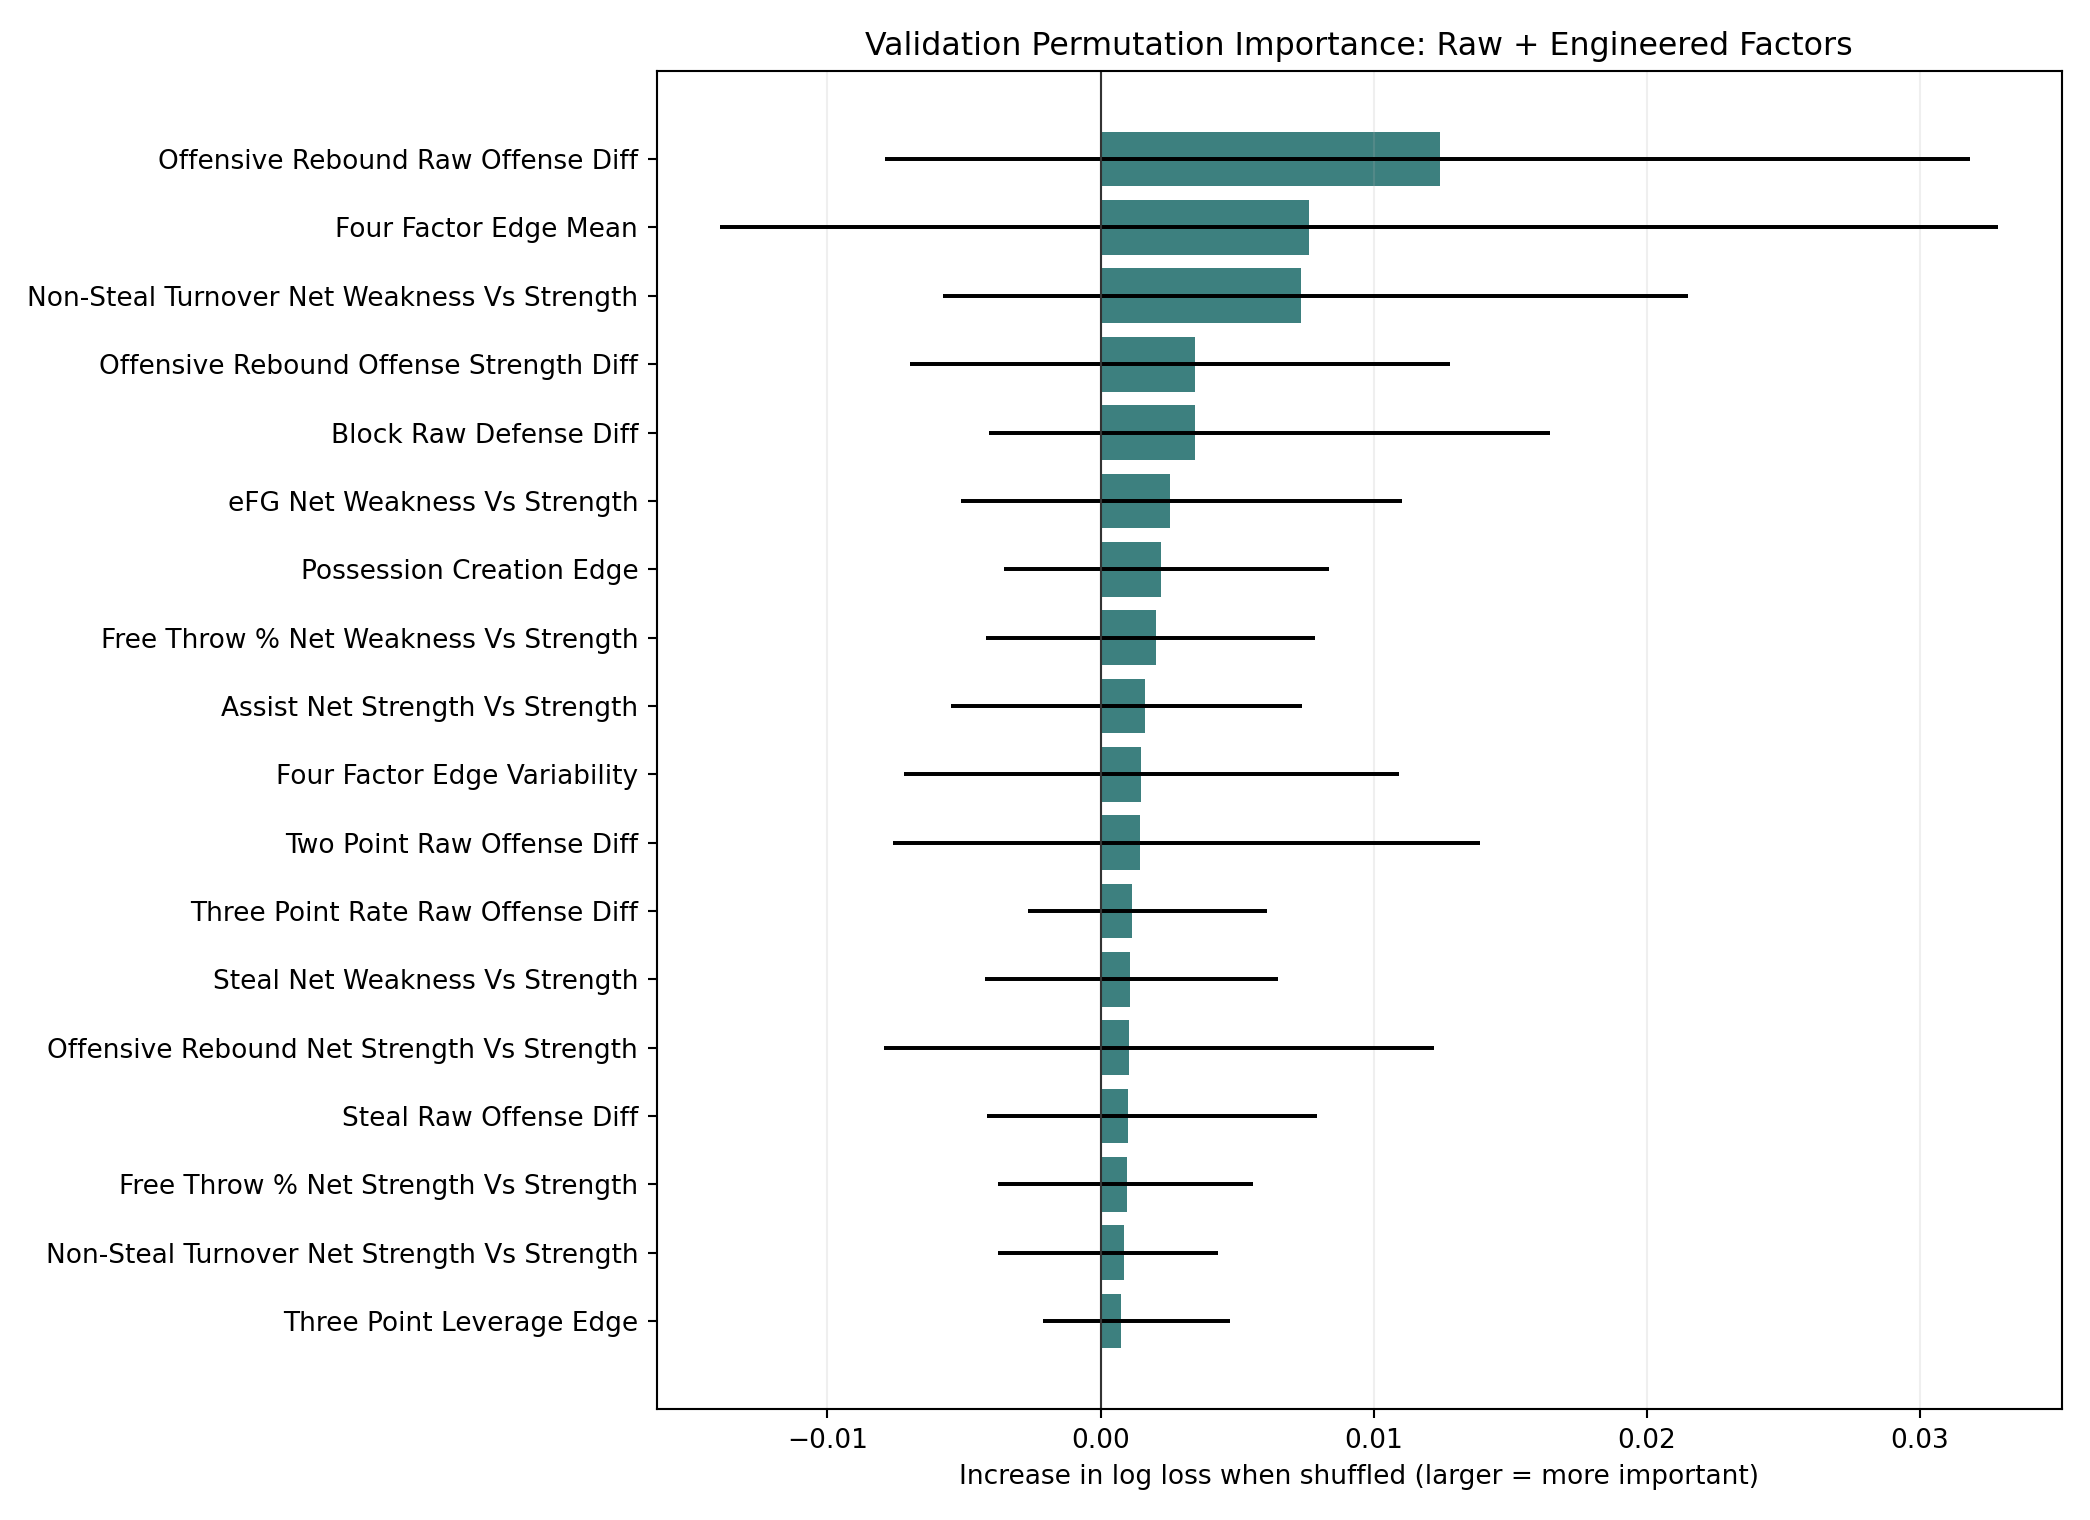

In [5]:
display(Image(filename=str(FIGURES / "feature_importance.png")))

## 4. Grouped Factor Importance

Correlated engineered variables can split credit. This chart shuffles each
basketball concept as a block and shows its importance range across logistic
regression, decision tree, random forest, and gradient boosting.

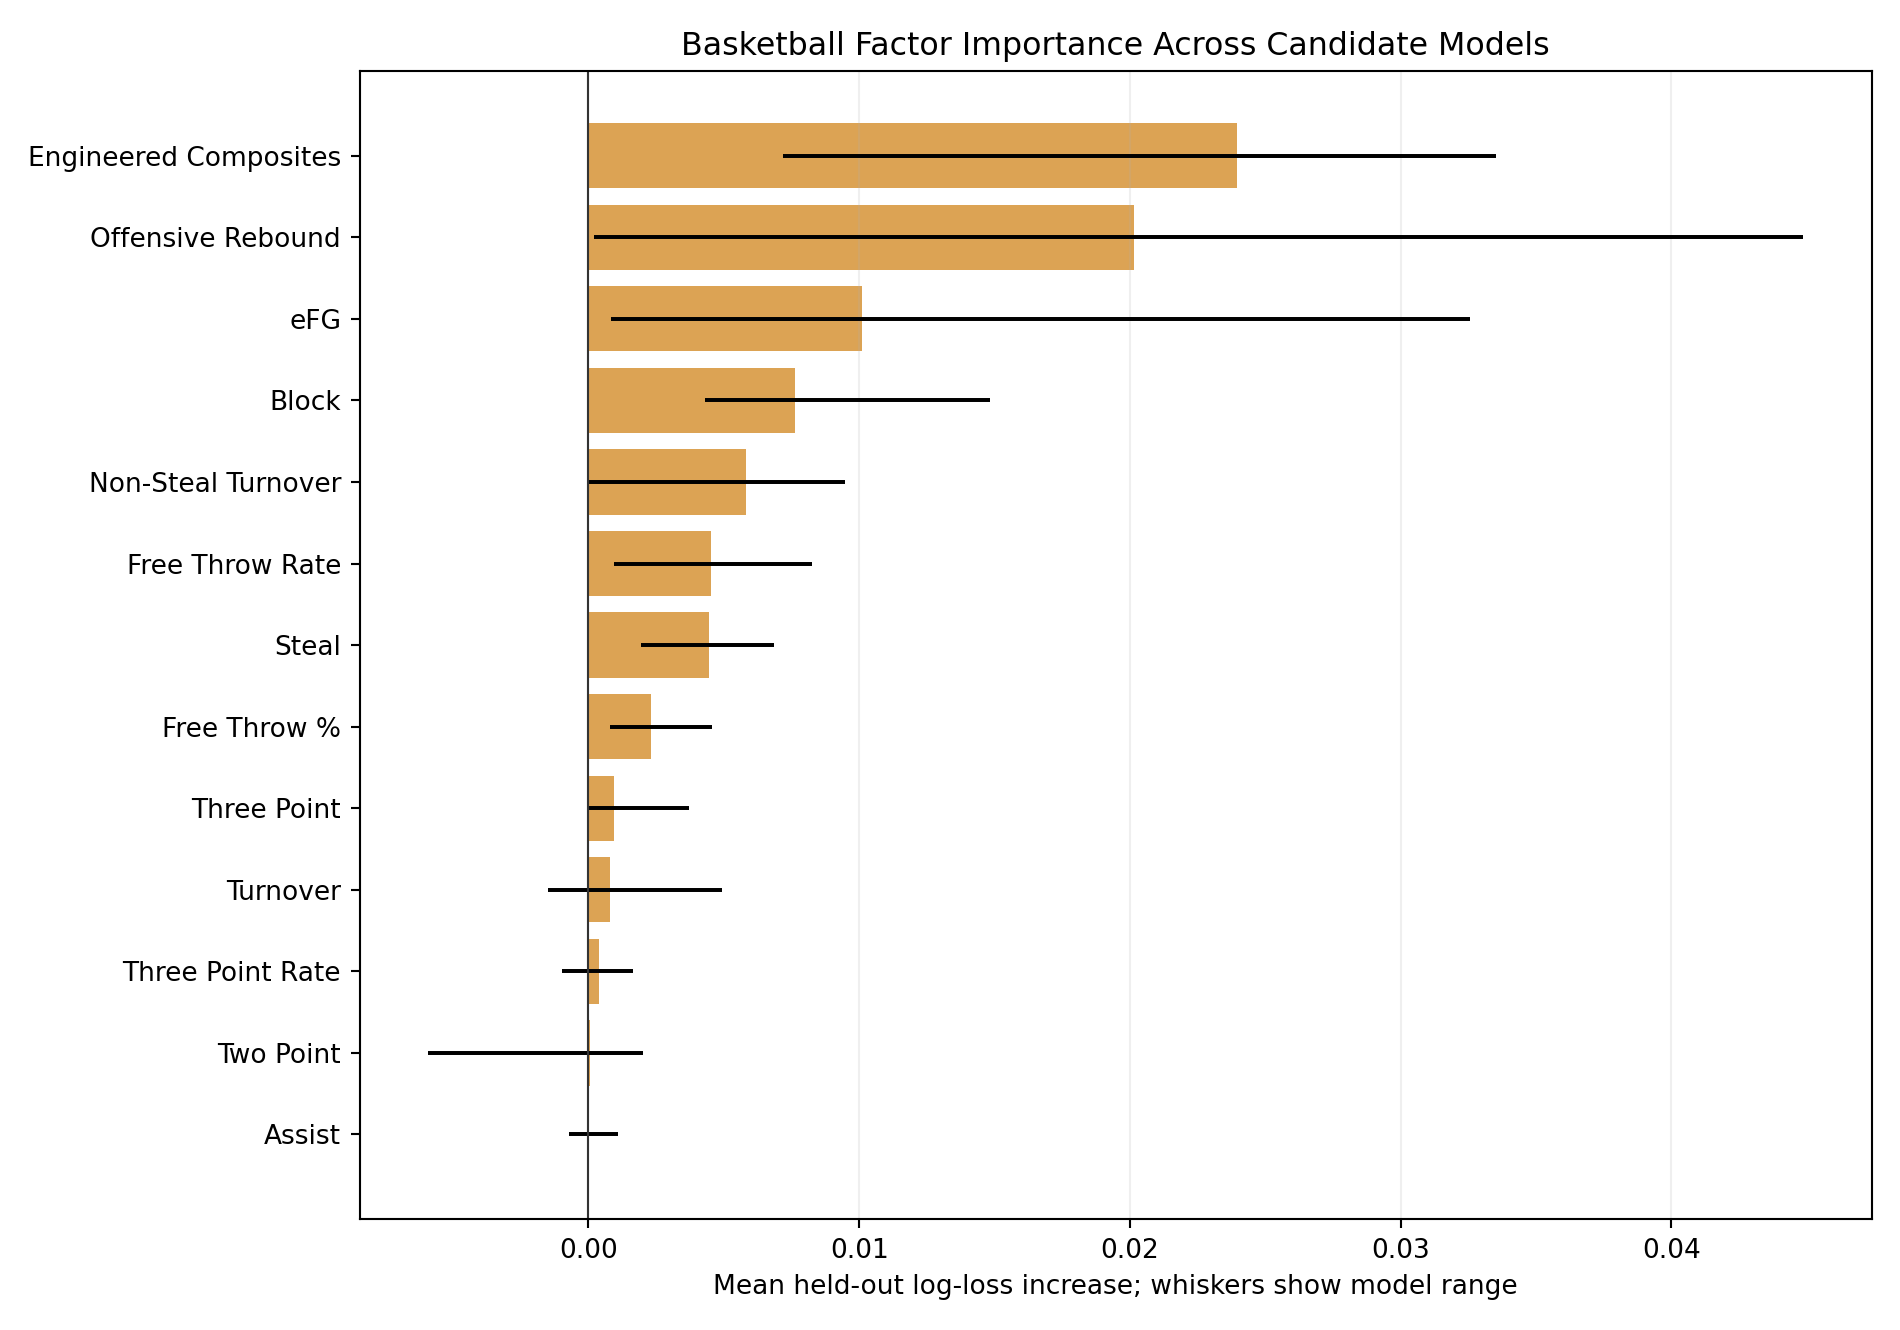

In [6]:
display(Image(filename=str(FIGURES / "group_importance.png")))

## 5. Raw Rates And Matchup Mechanisms

This view directly compares the importance of raw percentage-point
differences, ordinary percentile strengths, strength-vs-strength,
strength-vs-weakness, and the remaining engineered mechanisms.

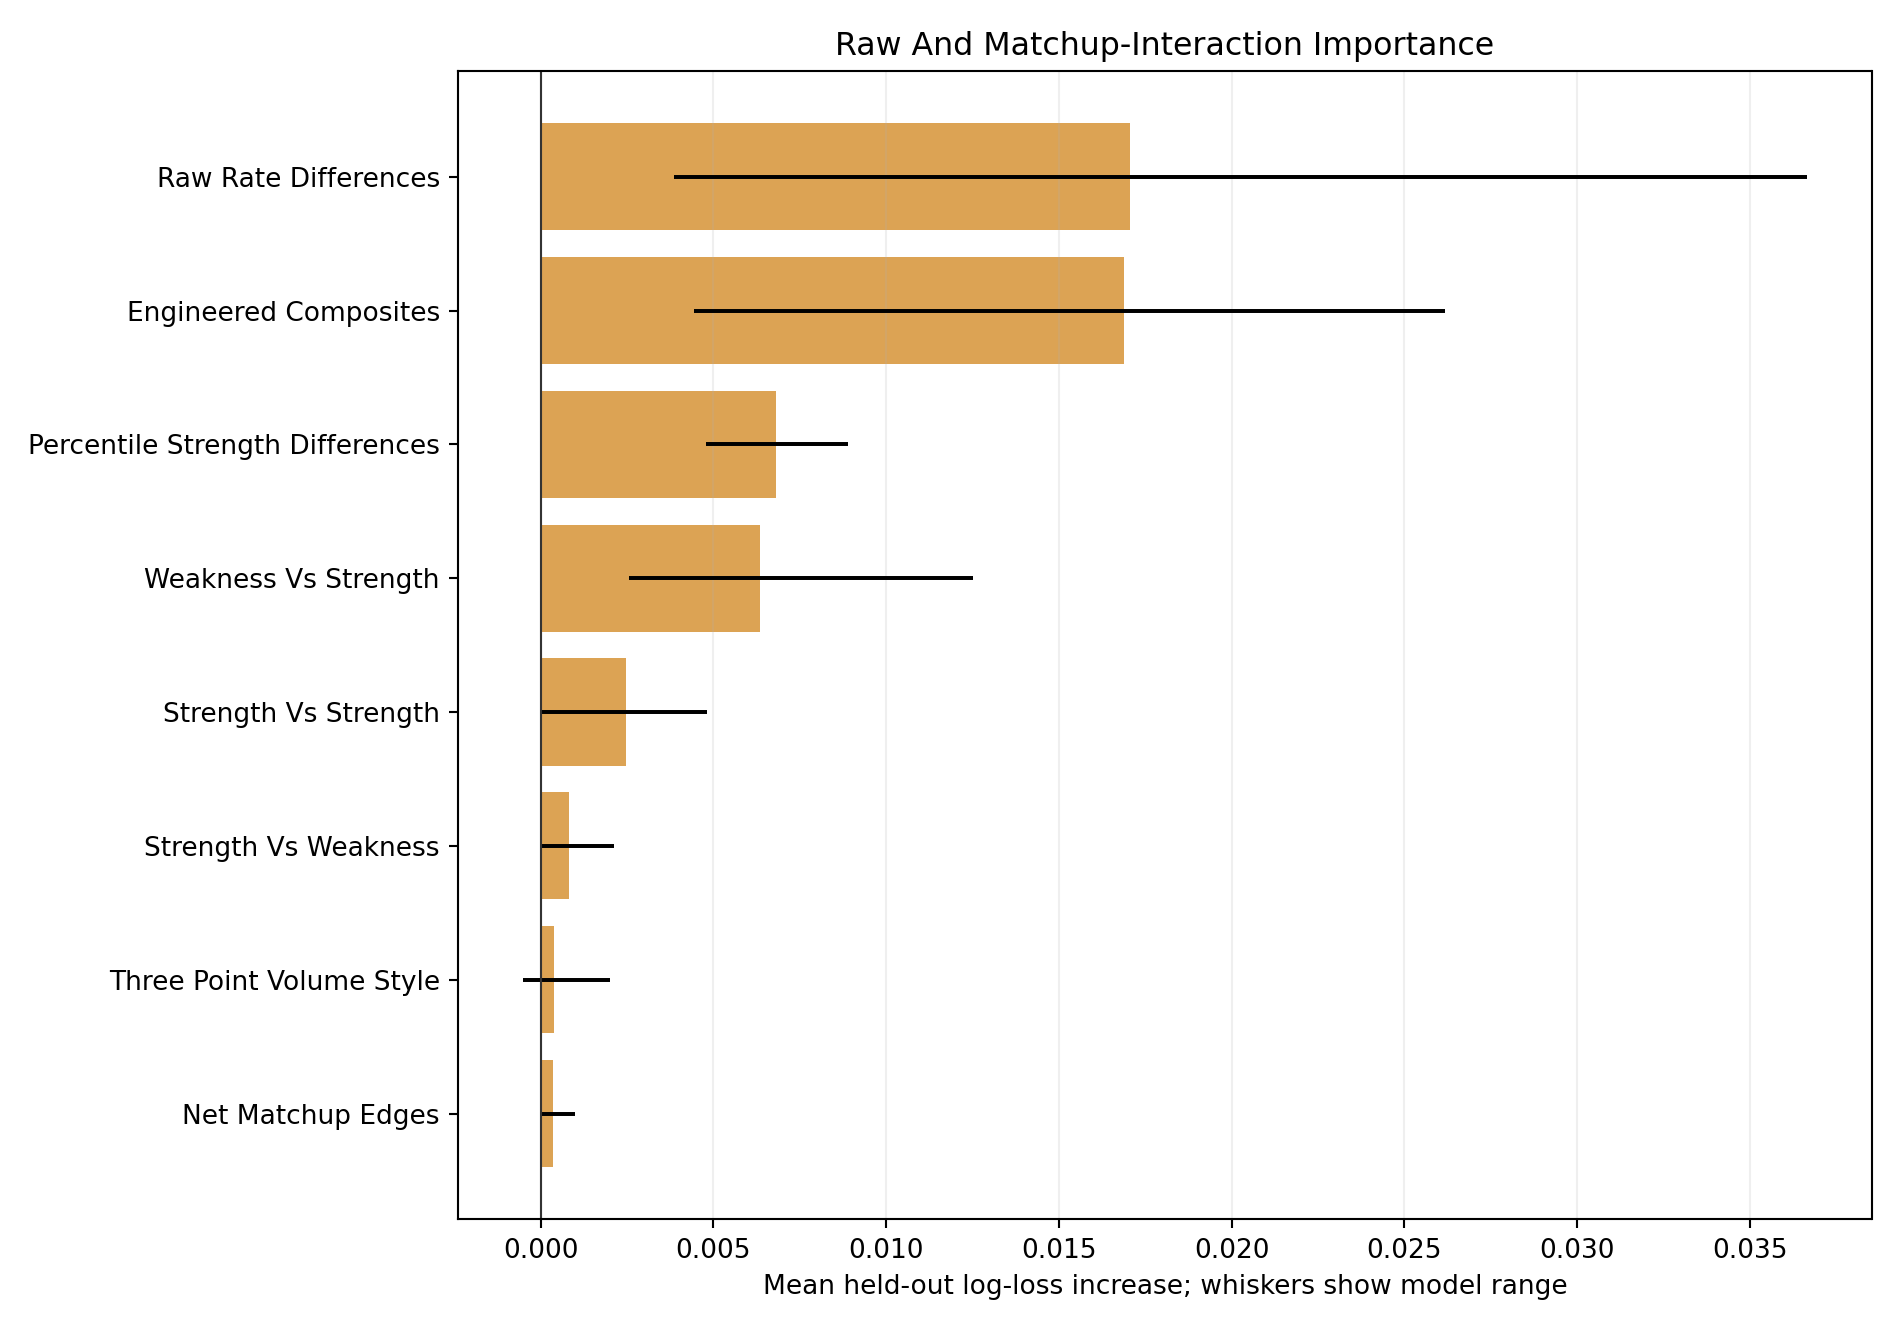

In [7]:
display(Image(filename=str(FIGURES / "interaction_importance.png")))

## 6. Model Diagnostics

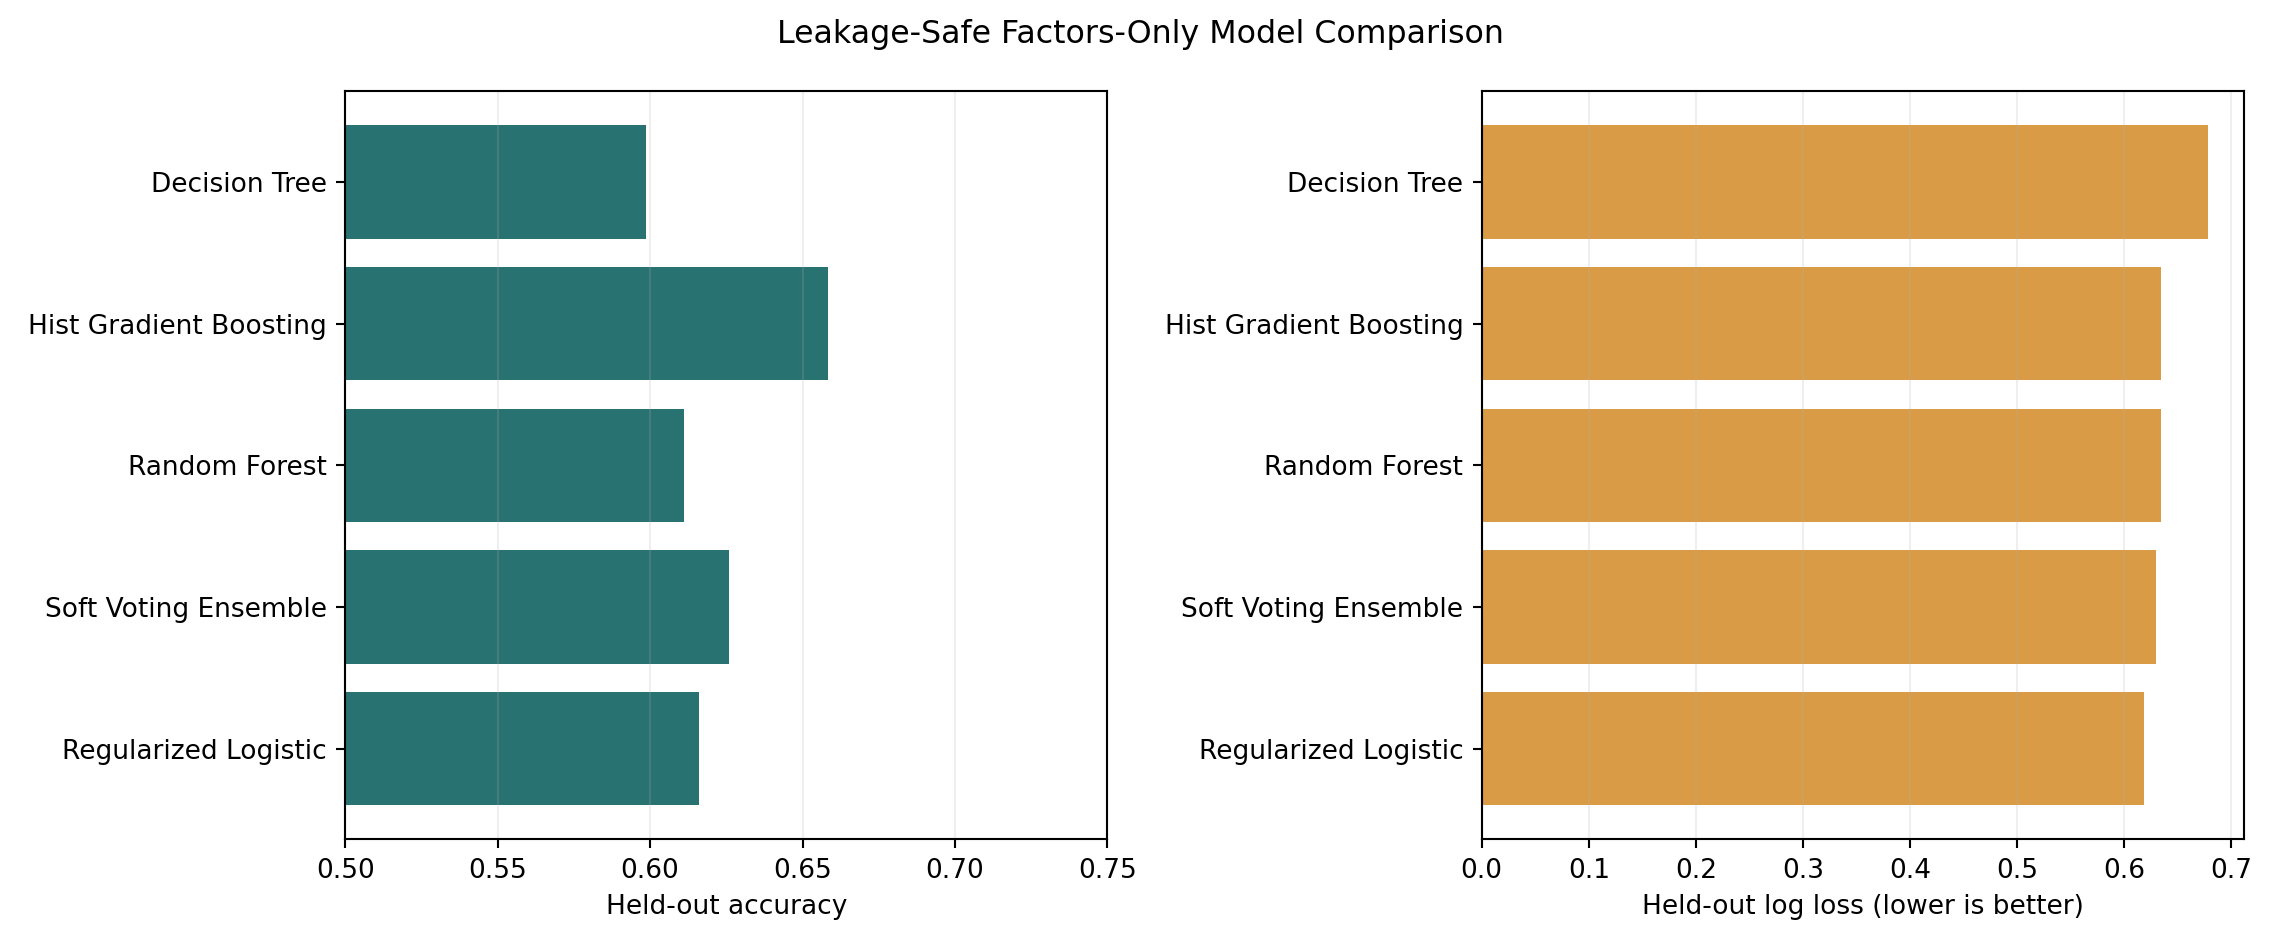

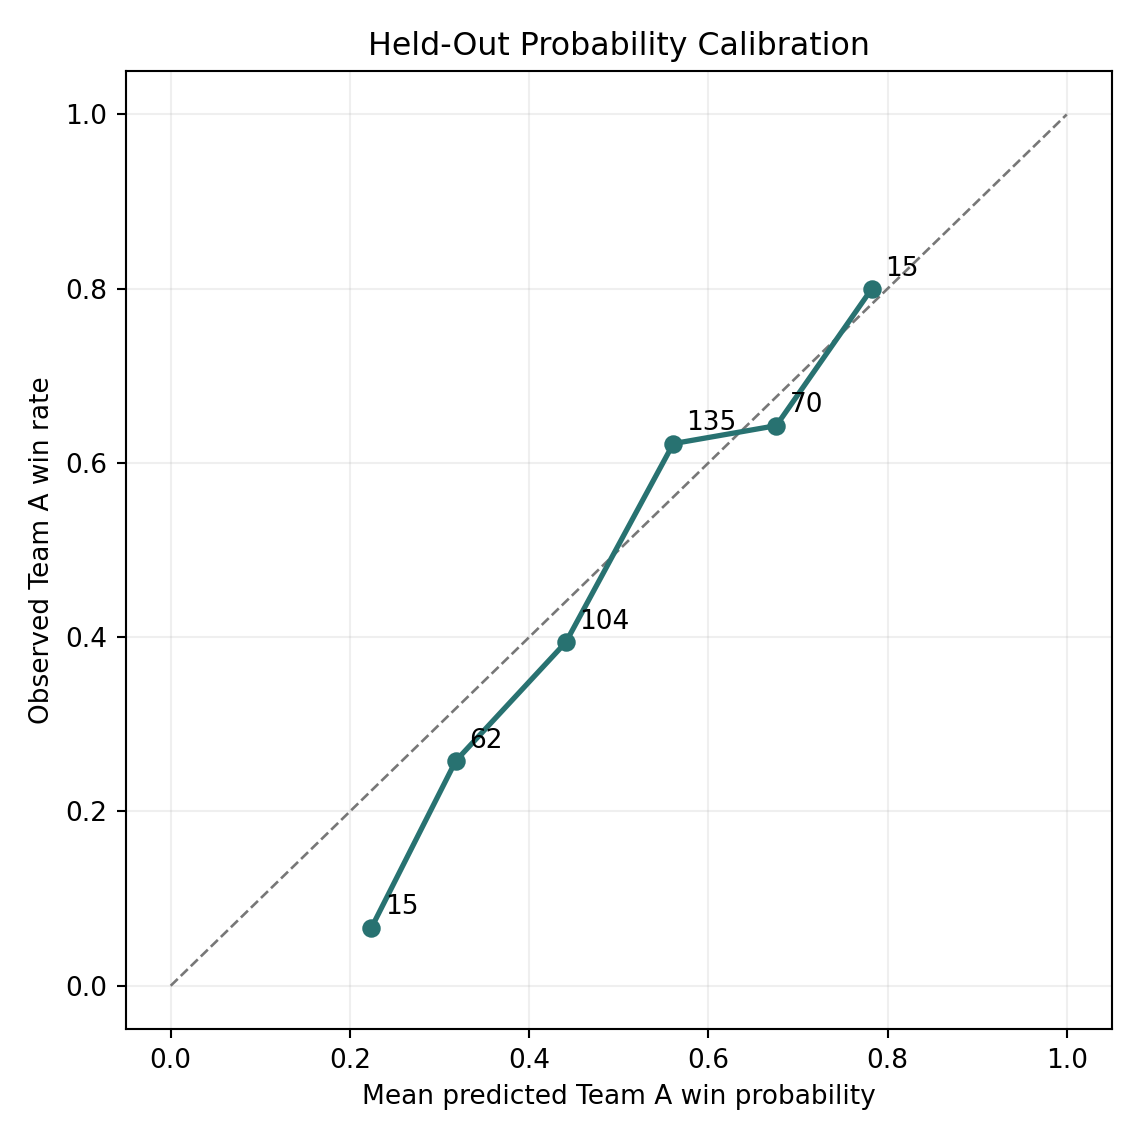

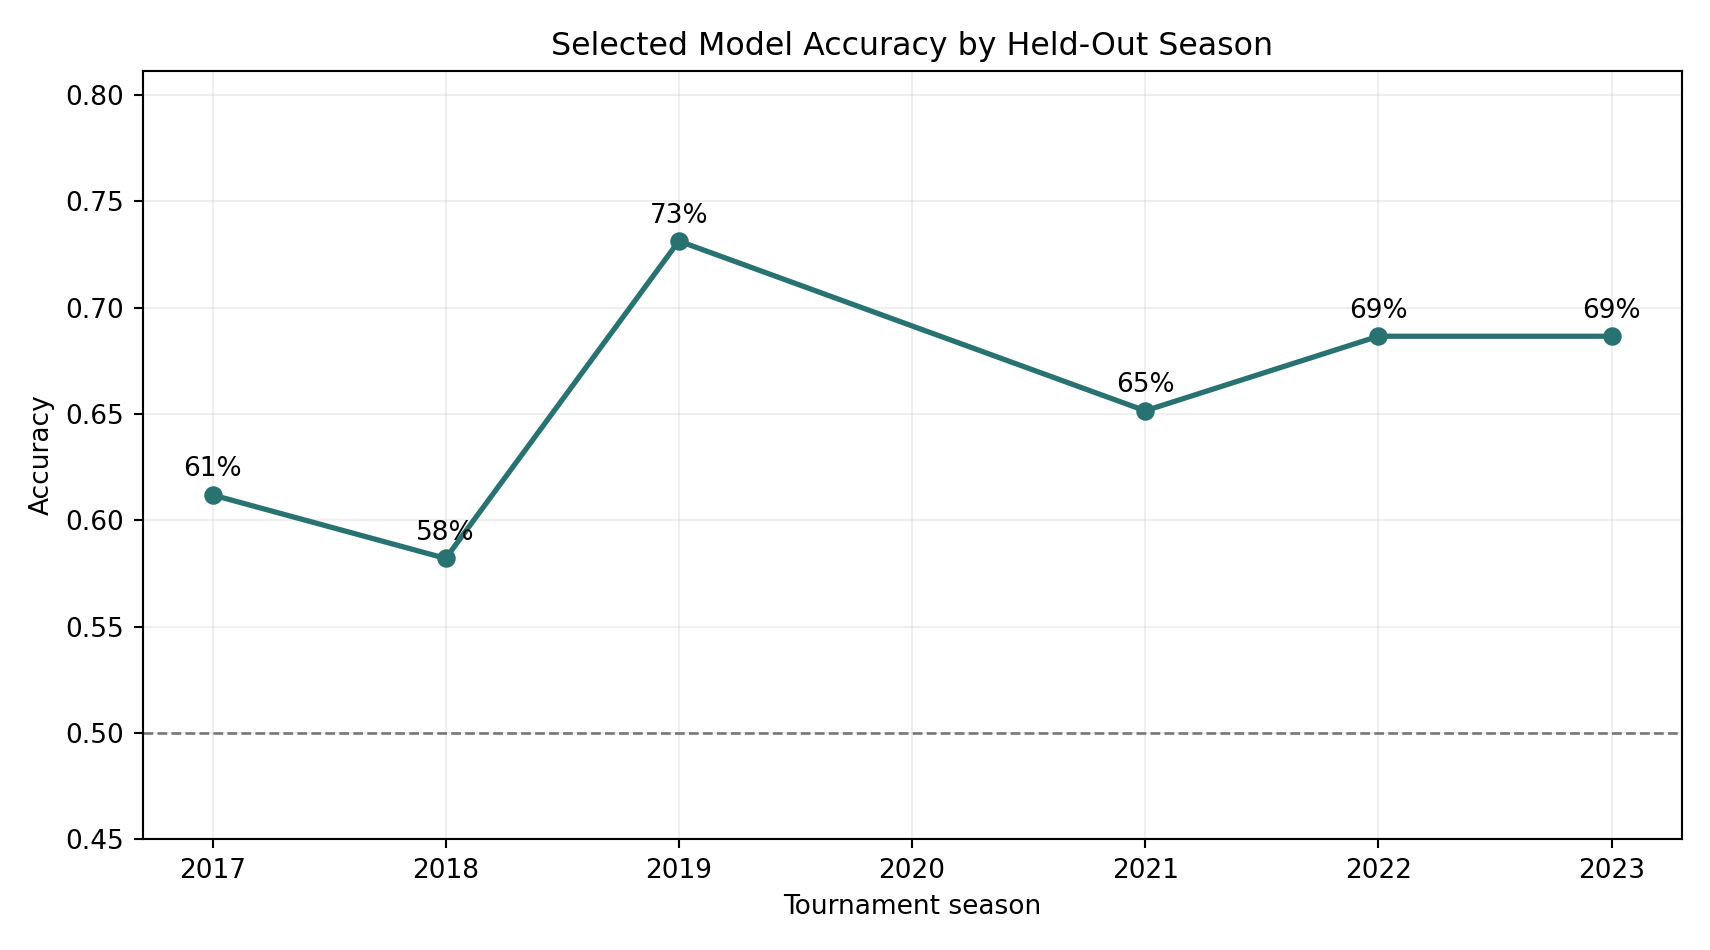

In [8]:
display(Image(filename=str(FIGURES / "model_comparison.png")))
display(Image(filename=str(FIGURES / "calibration.png")))
display(Image(filename=str(FIGURES / "accuracy_by_year.png")))

## 7. Strength Matchups

These descriptive held-out rates compare strong and weak offenses with strong
and weak defenses. Cells with fewer than ten games are suppressed.

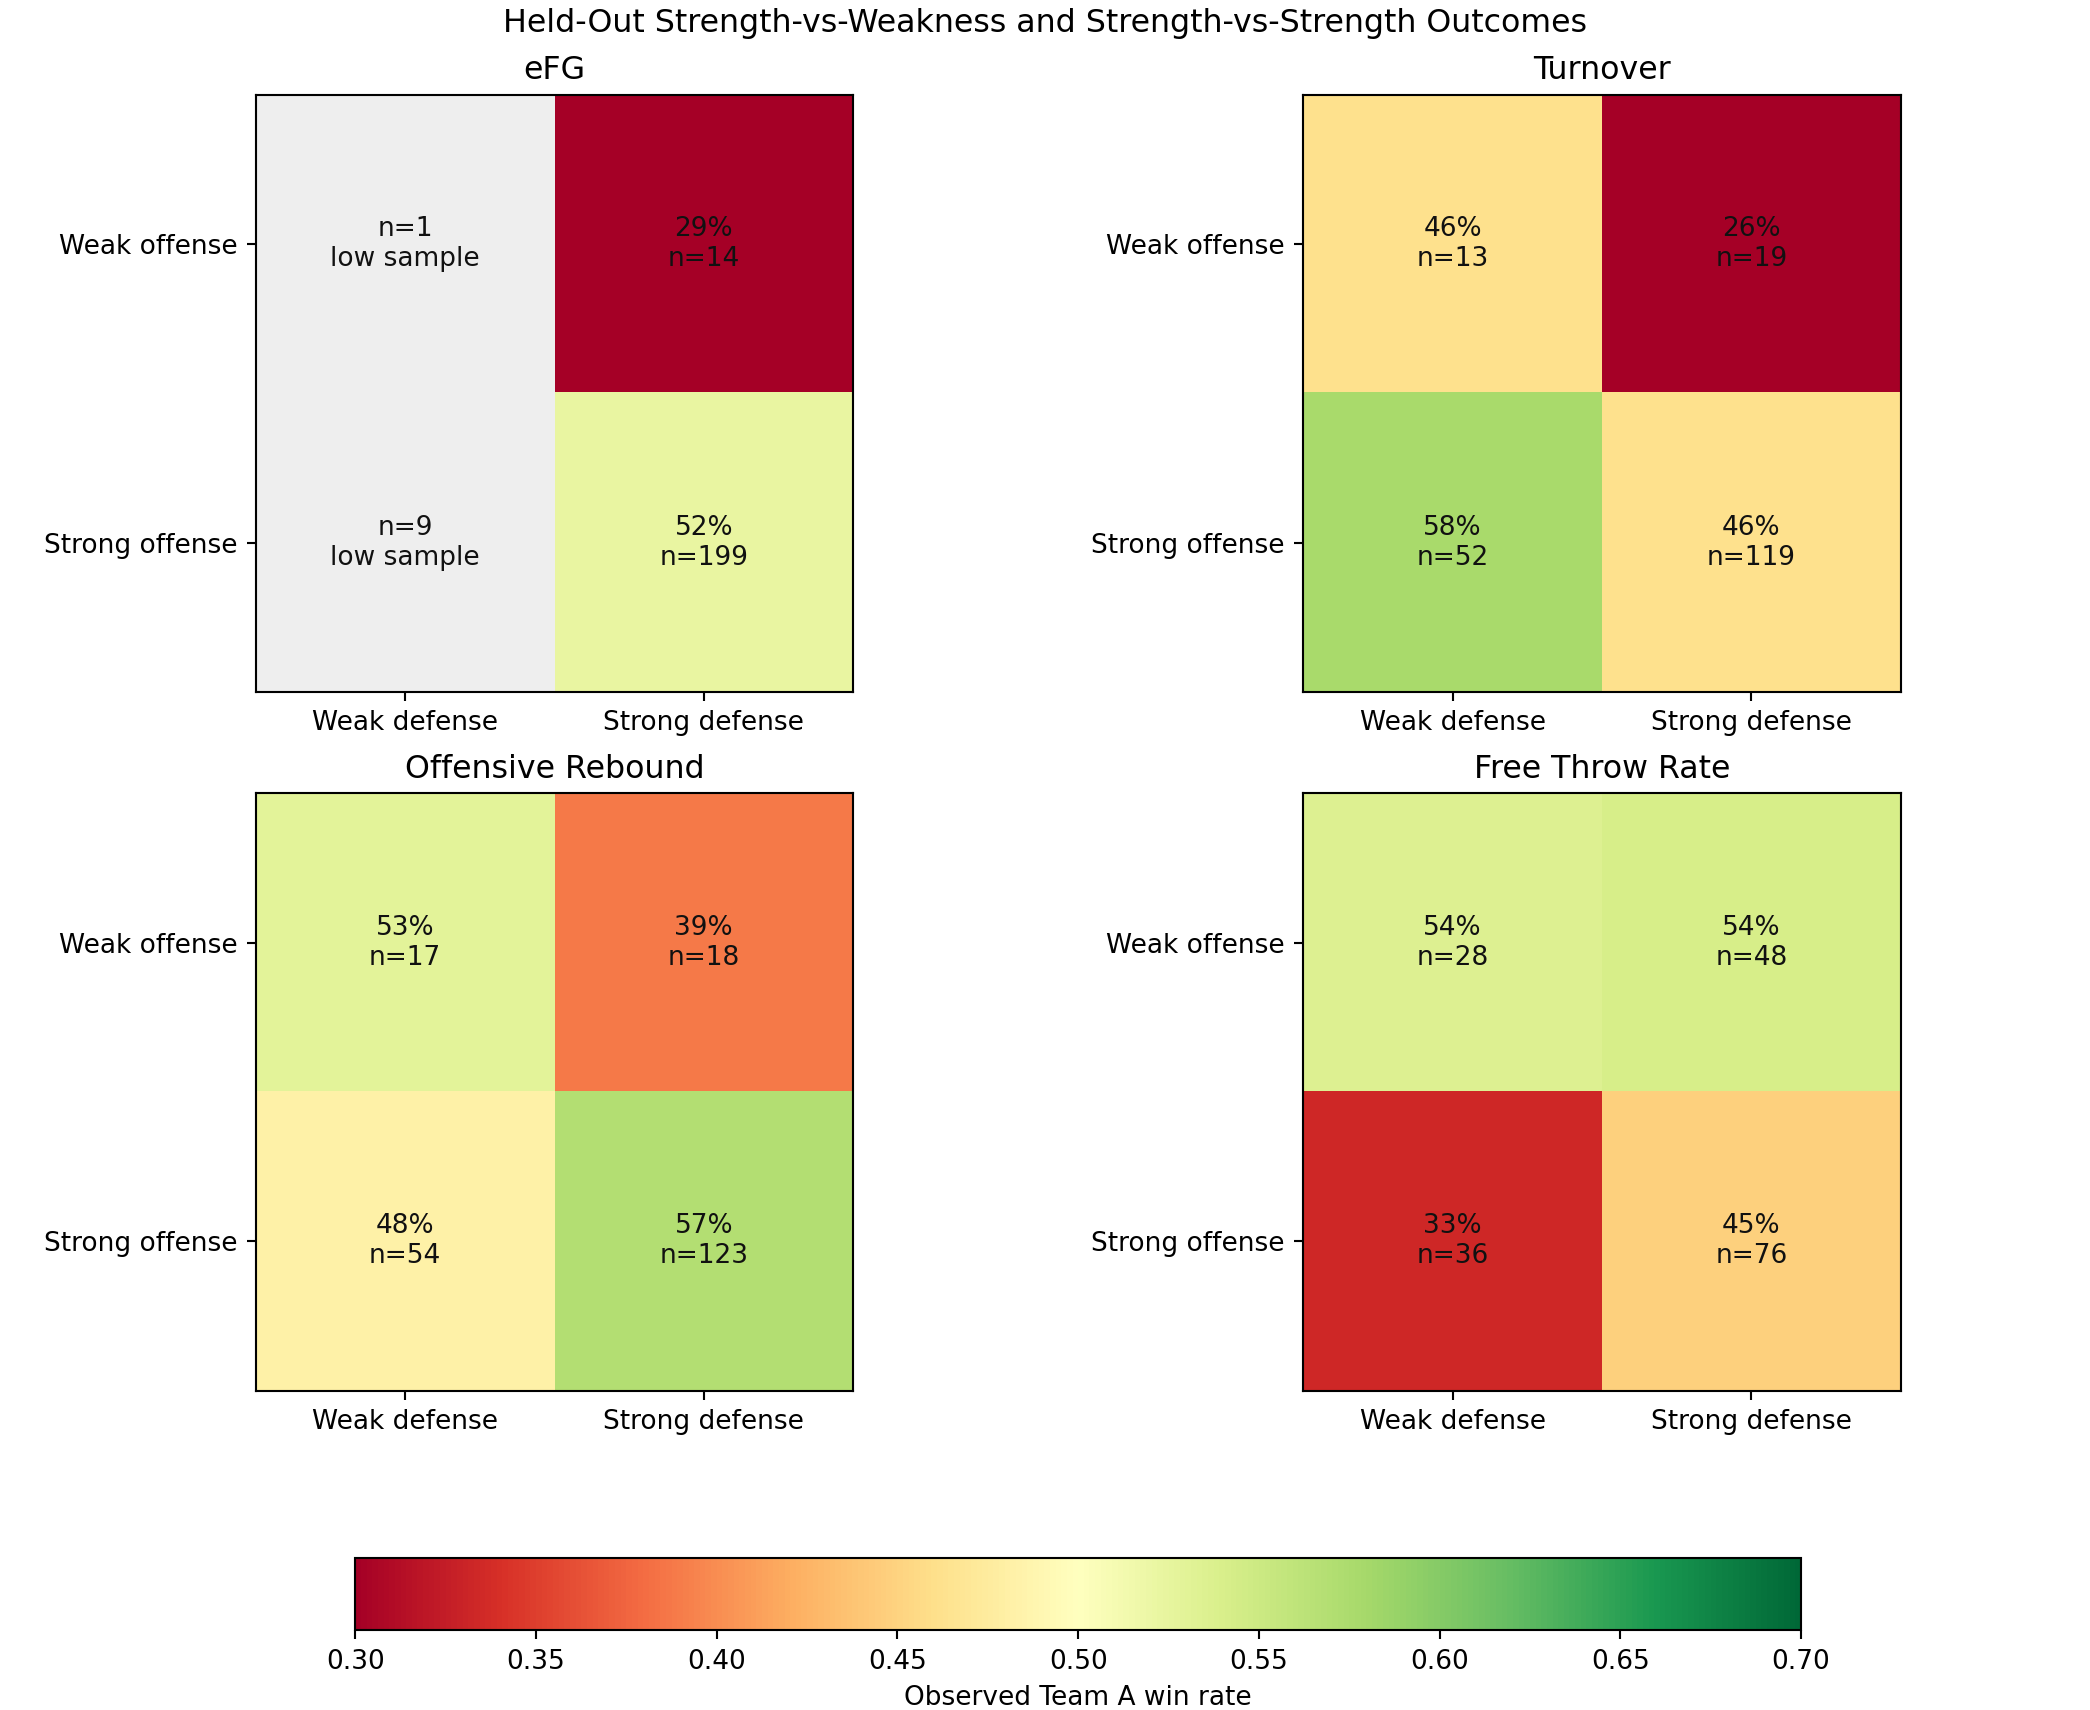

In [9]:
display(Image(filename=str(FIGURES / "matchup_quadrants.png")))

## 8. Detailed Results

Seeds appear only in the post-prediction upset diagnostic and never enter the
model. Permutation importance measures predictive reliance, not causality.

In [10]:
feature_importance = pd.read_csv(REPORTS / "feature_importance.csv")
group_importance = pd.read_csv(REPORTS / "group_importance.csv")
interaction_importance = pd.read_csv(REPORTS / "interaction_importance.csv")
hyperparameter_tuning = pd.read_csv(REPORTS / "hyperparameter_tuning.csv")
rolling_validation = pd.read_csv(REPORTS / "rolling_validation.csv")
upset_analysis = pd.read_csv(REPORTS / "upset_analysis.csv")

display(feature_importance.head(20))
display(group_importance.head(20))
display(interaction_importance.head(20))
display(upset_analysis)
rolling_validation[rolling_validation["model"].eq(metrics["selected_model"])]

,feature,family,importance_mean,importance_std,importance_low,importance_high,positive_fraction,positive_season_fraction,rank
0,offensive_rebound_raw_off_diff,offensive_rebound,0.012433,0.010465,-0.007884,0.031835,0.883333,1.000000,1
1,four_factor_edge_mean,engineered_composites,0.007650,0.012358,-0.013918,0.032855,0.725000,1.000000,2
2,nonsteal_turnover_net_weakness_vs_strength,nonsteal_turnover,0.007354,0.007113,-0.005770,0.021515,0.883333,1.000000,3
3,offensive_rebound_off_strength_diff,offensive_rebound,0.003453,0.005643,-0.006994,0.012787,0.708333,0.833333,4
4,block_raw_def_diff,block,0.003450,0.005481,-0.004094,0.016461,0.700000,0.666667,5
5,efg_net_weakness_vs_strength,efg,0.002549,0.004449,-0.005095,0.011040,0.675000,0.833333,6
6,possession_creation_edge,engineered_composites,0.002226,0.003189,-0.003533,0.008361,0.741667,0.666667,7
7,free_throw_pct_net_weakness_vs_strength,free_throw_pct,0.002033,0.003408,-0.004184,0.007860,0.733333,0.833333,8
8,assist_net_strength_vs_strength,assist,0.001638,0.003564,-0.005465,0.007376,0.666667,0.666667,9
9,four_factor_edge_std,engineered_composites,0.001499,0.004578,-0.007189,0.010917,0.633333,0.666667,10


,model,factor_group,feature_count,importance_mean,importance_std,positive_fraction
0,decision_tree,engineered_composites,15,0.027372,0.013254,1.000000
1,decision_tree,free_throw_rate,9,0.008268,0.004629,0.900000
2,decision_tree,turnover,9,0.004947,0.003120,1.000000
3,decision_tree,block,9,0.004315,0.003547,0.933333
4,decision_tree,steal,9,0.003705,0.001396,1.000000
5,decision_tree,three_point_rate,6,0.001654,0.001341,0.866667
6,decision_tree,efg,9,0.000838,0.003749,0.533333
7,decision_tree,free_throw_pct,9,0.000788,0.001162,0.766667
8,decision_tree,offensive_rebound,9,0.000215,0.001799,0.600000
9,decision_tree,three_point,9,0.000000,0.000000,0.000000


,model,factor_group,feature_count,importance_mean,importance_std,positive_fraction
0,decision_tree,engineered_composites,13,0.026163,0.011365,1.000000
1,decision_tree,percentile_strength_differences,33,0.008886,0.005583,0.933333
2,decision_tree,weakness_vs_strength,11,0.004218,0.003004,0.900000
3,decision_tree,raw_rate_differences,24,0.003855,0.010108,0.600000
4,decision_tree,three_point_volume_style,4,0.001993,0.001438,0.933333
5,decision_tree,net_matchup_edges,11,0.000000,0.000000,0.000000
6,decision_tree,strength_vs_strength,12,0.000000,0.000000,0.000000
7,decision_tree,strength_vs_weakness,12,0.000000,0.000000,0.000000
8,hist_gradient_boosting,raw_rate_differences,24,0.019557,0.004923,1.000000
9,hist_gradient_boosting,engineered_composites,13,0.019140,0.005272,1.000000


,segment,games,accuracy,mean_confidence
0,actual_upsets,113,0.353982,0.610493
1,favorite_wins,288,0.777778,0.617514
2,all_seeded_games,401,0.658354,0.615535


,model,season,games,accuracy,brier,log_loss,roc_auc
3,hist_gradient_boosting,2017,67,0.597015,0.229954,0.652757,0.682143
8,hist_gradient_boosting,2018,67,0.611940,0.237951,0.672182,0.630357
13,hist_gradient_boosting,2019,67,0.716418,0.197147,0.577117,0.775926
18,hist_gradient_boosting,2021,66,0.636364,0.222620,0.631044,0.684259
23,hist_gradient_boosting,2022,67,0.656716,0.217958,0.633386,0.701452
28,hist_gradient_boosting,2023,67,0.656716,0.210582,0.607770,0.718919


## 9. Saved Summary

In [11]:
display(Markdown((REPORTS / "summary.md").read_text()))

# Trustworthy Four Factors + Misc Importance Analysis

## Data timing

Features are computed only from NCAA regular-season detailed box scores. Tournament results are stored separately, so the feature snapshot is confirmed pre-tournament rather than inferred from a season-end KenPom page.

## Selected model

- Model: Hist Gradient Boosting
- Held-out accuracy: 0.658
- Held-out ROC AUC: 0.694
- Held-out log loss: 0.634
- Accuracy 95% Wilson interval: 0.611-0.703
- Importance interpretation gate passed: True
- Model selection basis: hyperparameters tuned by pre-2017 expanding-window cross-validation; model family selected by calibrated accuracy on the requested 2017-2025 validation period

## Most important features

- Offensive Rebound Raw Offense Diff: 0.0124 mean held-out log-loss increase; positive in 100% of seasons
- Four Factor Edge Mean: 0.0077 mean held-out log-loss increase; positive in 100% of seasons
- Non-Steal Turnover Net Weakness Vs Strength: 0.0074 mean held-out log-loss increase; positive in 100% of seasons
- Offensive Rebound Offense Strength Diff: 0.0035 mean held-out log-loss increase; positive in 83% of seasons
- Block Raw Defense Diff: 0.0035 mean held-out log-loss increase; positive in 67% of seasons
- eFG Net Weakness Vs Strength: 0.0025 mean held-out log-loss increase; positive in 83% of seasons
- Possession Creation Edge: 0.0022 mean held-out log-loss increase; positive in 67% of seasons
- Free Throw % Net Weakness Vs Strength: 0.0020 mean held-out log-loss increase; positive in 83% of seasons

## Factor-group consensus

- Engineered Composites: 0.0239
- Offensive Rebound: 0.0201
- eFG: 0.0101
- Block: 0.0076
- Non-Steal Turnover: 0.0058
- Free Throw Rate: 0.0045
- Steal: 0.0045
- Free Throw %: 0.0023
- Three Point: 0.0009
- Turnover: 0.0008
- Three Point Rate: 0.0004
- Two Point: 0.0000
- Assist: -0.0001

## Matchup-mechanism importance

- Raw Rate Differences: 0.0170
- Engineered Composites: 0.0169
- Percentile Strength Differences: 0.0068
- Weakness Vs Strength: 0.0064
- Strength Vs Strength: 0.0025
- Strength Vs Weakness: 0.0008
- Three Point Volume Style: 0.0004
- Net Matchup Edges: 0.0003

## Upset behavior

- Actual Upsets: 0.354 accuracy across 113 games
- Favorite Wins: 0.778 accuracy across 288 games
- All Seeded Games: 0.658 accuracy across 401 games

## Interpretation guardrails

Permutation importance measures predictive reliance, not causality. Correlated engineered features share credit, which is why the grouped chart and cross-model range are more reliable than a single feature's exact rank.
Tournament seeds, KenPom rank, net rating, luck, and adjusted efficiency are excluded from model features. Seeds are used only after prediction to label upset evaluation segments.
